In [1]:
# Import modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_excel('compost_dataset_3.xlsx')
df.head()


,Waste type,Initial pH,Initial carbon to nitrogen,Initial moisture content (%),Compost time (day),pH,Temperature (℃),Moisture content (%),EC（ms/cm-1）,Ammonia(mg/kg,...,Change in total organiz carbon (%),Change in organic matter content (%),C/N,GI (%),NH4+-N (g/Kg),NO3--N (g/Kg),CO2 (g/Kg),CH4 (g/Kg),N2O (g/Kg),NH3 (g/Kg)
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,sludge waste composting,8.01378,10.054,53.668,0.0,29.772,53.668,8.01378,3.9202,42.270,...,24.773056,44.848,10.054,48.778,NaN,NaN,NaN,NaN,NaN,NaN
2,sludge waste composting,8.01378,10.054,53.668,2.0,43.537,50.151,7.35213,4.2153,207.220,...,18.139674,44.470,8.149,31.122,NaN,NaN,NaN,NaN,NaN,NaN
3,sludge waste composting,8.01378,10.054,53.668,5.0,79.707,41.357,18.08800,18.0880,18.088,...,18.088000,43.838,7.600,29.925,NaN,NaN,NaN,NaN,NaN,NaN
4,sludge waste composting,8.01378,10.054,53.668,10.0,80.026,42.487,7.28697,2.9660,171.130,...,19.496582,43.207,8.339,51.471,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Remove rows that are entirely empty
df_cleaned = df.dropna(how='all').reset_index(drop=True)

# Select and clean variables for analysis
# Dropping rows where GI (%) is NaN is essential for these comparisons
analysis_df = df_cleaned.dropna(subset=['GI (%)'])

# Export cleaned data
analysis_df.to_csv('cleaned_compost_data_2.csv', index=False)

In [7]:
# Load the cleaned data
df = pd.read_csv('cleaned_compost_data_2.csv')
df.head()

,Waste type,Initial pH,Initial carbon to nitrogen,Initial moisture content (%),Compost time (day),pH,Temperature (℃),Moisture content (%),EC（ms/cm-1）,Ammonia(mg/kg,...,Change in total organiz carbon (%),Change in organic matter content (%),C/N,GI (%),NH4+-N (g/Kg),NO3--N (g/Kg),CO2 (g/Kg),CH4 (g/Kg),N2O (g/Kg),NH3 (g/Kg)
0,sludge waste composting,8.01378,10.054,53.668,0.0,29.772,53.668,8.01378,3.9202,42.270,...,24.773056,44.848,10.054,48.778,NaN,NaN,NaN,NaN,NaN,NaN
1,sludge waste composting,8.01378,10.054,53.668,2.0,43.537,50.151,7.35213,4.2153,207.220,...,18.139674,44.470,8.149,31.122,NaN,NaN,NaN,NaN,NaN,NaN
2,sludge waste composting,8.01378,10.054,53.668,5.0,79.707,41.357,18.08800,18.0880,18.088,...,18.088000,43.838,7.600,29.925,NaN,NaN,NaN,NaN,NaN,NaN
3,sludge waste composting,8.01378,10.054,53.668,10.0,80.026,42.487,7.28697,2.9660,171.130,...,19.496582,43.207,8.339,51.471,NaN,NaN,NaN,NaN,NaN,NaN
4,sludge waste composting,8.01378,10.054,53.668,17.0,79.858,44.246,7.17168,2.7451,125.770,...,21.855456,44.217,10.841,53.267,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
df.columns

Index(['Waste type', 'Initial pH ', 'Initial carbon to nitrogen',
       'Initial moisture content (%)', 'Compost time (day)', 'pH',
       'Temperature (℃)', 'Moisture content (%)', 'EC（ms/cm-1）',
       'Ammonia(mg/kg', 'Nitrate(mg/kg)', 'Total nitrogen (%)',
       'Change in total organiz carbon (%)',
       'Change in organic matter content (%)', 'C/N', 'GI (%)',
       'NH4+-N (g/Kg)', 'NO3--N (g/Kg)', 'CO2 (g/Kg)', 'CH4 (g/Kg)',
       'N2O (g/Kg)', 'NH3 (g/Kg)'],
      dtype='str')

In [9]:
# Filtered only relevant columns for analysis
cols = ['Compost time (day)', 'pH', 'Temperature (℃)', 'Moisture content (%)', 'GI (%)', 'C/N']
df = df[cols].dropna()
df.head()

,Compost time (day),pH,Temperature (℃),Moisture content (%),GI (%),C/N
0,0.0,29.772,53.668,8.01378,48.778,10.054
1,2.0,43.537,50.151,7.35213,31.122,8.149
2,5.0,79.707,41.357,18.08800,29.925,7.600
3,10.0,80.026,42.487,7.28697,51.471,8.339
4,17.0,79.858,44.246,7.17168,53.267,10.841


In [10]:
# Grouping by composting stage
bins   = [0, 7, 14, 21, 30, 60, 185]
labels = ['0–7', '8–14', '15–21', '22–30', '31–60', '61+']

df['stage'] = pd.cut(df['Compost time (day)'], bins=bins, labels=labels, include_lowest=True)
grouped = df.groupby('stage', observed=True).mean().round(2)
print(grouped)

       Compost time (day)     pH  Temperature (℃)  Moisture content (%)  \
stage                                                                     
0–7                  2.85  36.07            56.14                 17.74   
8–14                11.37  38.34            51.49                 13.04   
15–21               18.36  29.66            45.94                 12.69   
22–30               27.06  27.04            39.16                 13.37   
31–60               42.97  18.82            38.66                 21.82   
61+                 87.82  12.88            32.81                 20.02   

       GI (%)    C/N  
stage                 
0–7     34.80  25.42  
8–14    58.58  19.20  
15–21   75.00  16.96  
22–30   80.69  15.36  
31–60   79.11  17.17  
61+     86.12  17.73  


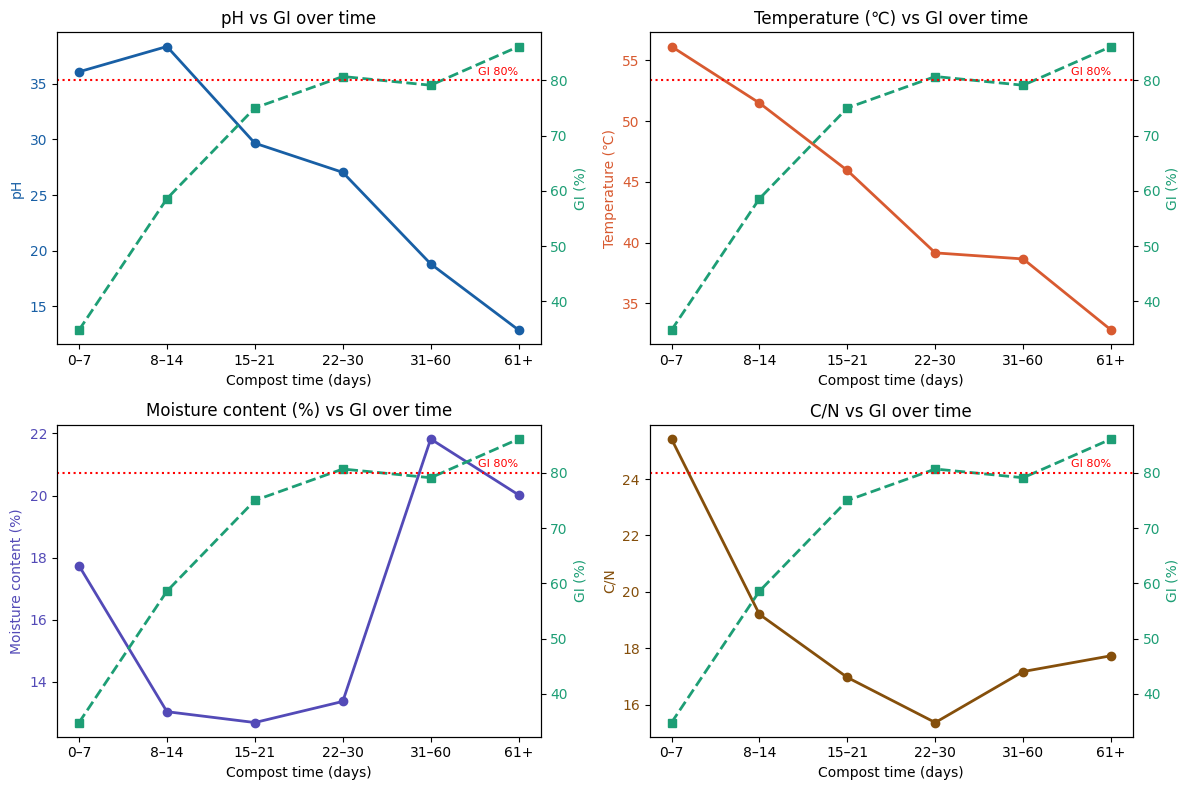

In [15]:
# Generated through Chat GPT
def plot_vs_gi(ax, var_name, color):
    ax2 = ax.twinx()                                   # second y-axis for GI
    ax.plot(labels, grouped[var_name], color=color,
            marker='o', linewidth=2, label=var_name)
    ax2.plot(labels, grouped['GI (%)'], color='#1D9E75',
             marker='s', linestyle='--', linewidth=2, label='GI (%)')
    
    ax2.axhline(y=80, color='red', linestyle=':', linewidth=1.5)        
    ax2.text(labels[-1], 81, 'GI 80%',                       
             color='red', fontsize=8, ha='right')

    ax.set_ylabel(var_name, color=color)
    ax2.set_ylabel('GI (%)', color='#1D9E75')
    ax.tick_params(axis='y', labelcolor=color)
    ax2.tick_params(axis='y', labelcolor='#1D9E75')
    ax.set_title(f'{var_name} vs GI over time')
    ax.set_xlabel('Compost time (days)')

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

vars_and_colors = [
    ('pH',                   '#185FA5'),
    ('Temperature (℃)',      '#D85A30'),
    ('Moisture content (%)', '#534AB7'),
    ('C/N',                  '#854F0B'),
]

for ax, (var, color) in zip(axes.flat, vars_and_colors):
    plot_vs_gi(ax, var, color)

plt.tight_layout()
plt.show()